In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import os
import scipy
import scanpy as sc

sc.set_figure_params(dpi=80)

from matplotlib.gridspec import GridSpec
from datetime import datetime
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

%config InlineBackend.figure_format='retina'


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
plotting_functions = lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))
thresholding_functions = lazy_import("thresholding_functions",os.path.join(utils_dir, "thresholding_functions.py"))

from general_utils import ismember, grep, grep_exclude, read_object, write_object
from thresholding_functions import threshold_triangle


In [ ]:
de = pd.read_csv("./ATAC_processing/multiome_PP20251110/DifferentialMotif/DESEQ20251116_FEATURES_p53_motif_canonical_noncanonicalchip200_MODE_coverage_BATCH_all_QUERY_progenitor_REFERENCE_gastric.tsv.gz", sep = "\t", index_col = 0)

In [ ]:
def load_coverage_information_asDataFrame(coverage_path):
    coverage = pd.read_csv(os.path.join(coverage_path, "coverage.tsv.gz"), sep = "\t")
    group_info = pd.read_csv(os.path.join(coverage_path, "group.tsv.gz"), sep = "\t")
    motif_info = pd.read_csv(os.path.join(coverage_path, "motif.tsv.gz"), sep = "\t")
    motif_info['motif_name'] = [x + ":" + str(y) + "-" + str(z) for x,y,z in zip(motif_info['seqnames'], motif_info['start'], motif_info['end'])]
    
    sparse_matrix = scipy.sparse.csr_matrix(
        (coverage['coverage'], (coverage['motif_index']-1, coverage['group_index']-1)),
        shape = [np.max(coverage['motif_index']), np.max(coverage['group_index'])]
    ).todense()
    df = pd.DataFrame(sparse_matrix)
    df.index = motif_info['motif_name'][:df.shape[0]]
    df.columns = group_info['group'][:df.shape[1]]
    norm_df = pd.read_csv(os.path.join(coverage_path, 'normalization_factor.tsv.gz'), sep = "\t")
    df = df / norm_df['normalization_factor'].to_numpy() * 10000
    return(df)

df_canonical = load_coverage_information_asDataFrame(
    "ATAC_processing/multiome_PP20251110/MotifCoverage/Sample_cell_type/DATABASE_homer_MOTIF_Trp53_canonical_GROUP_Sample_cell_type_FRAG_1_147"
)
df_canonical['motif_type'] = 'canonical'
df_noncanonical = load_coverage_information_asDataFrame(
    "ATAC_processing/multiome_PP20251110/MotifCoverage/Sample_cell_type/DATABASE_homer_MOTIF_Trp53_noncanonical_GROUP_Sample_cell_type_FRAG_1_147"
)
df_noncanonical['motif_type'] = 'noncanonical'
df_coverage = pd.concat([df_canonical, df_noncanonical], axis = 0)


In [ ]:
df_coverage.shape

(64167, 20)

In [ ]:
progenitor_columns = ['p489c_shRen_caer_48h_multiome_1_progenitor', 'p489c_shRen_caer_48h_multiome_2_progenitor','DACE657_mKate2_multiome_progenitor']
gastric_columns = ['p489c_shRen_caer_48h_multiome_1_gastric', 'p489c_shRen_caer_48h_multiome_2_gastric','DACE657_mKate2_multiome_gastric']


In [ ]:
# This filter removes motifs that were only found in one sample
df_coverage = df_coverage.loc[ismember(df_coverage.index, de.index)[1],:]
df_coverage_progenitor = df_coverage.loc[:, progenitor_columns].copy()
df_coverage_gastric = df_coverage.loc[:, gastric_columns].copy()

# Identify motifs selectively bound in progenitor-like cells
pval_filter = de['padj'] < 0.05
logfold_filter = de['log2FoldChange'] > 1
bound_filter = de['p53_ChIP_200'] == True
progenitor_motifs = de.index[np.logical_and(pval_filter, logfold_filter)].to_numpy()
progenitor_bound = de.index[np.logical_and(np.logical_and(pval_filter, logfold_filter), bound_filter)].to_numpy()

# Identify motifs selectively bound in gastric-like cells
pval_filter = de['padj'] < 0.05
logfold_filter = de['log2FoldChange'] < -1
bound_filter = de['p53_ChIP_200'] == True
gastric_motifs = de.index[np.logical_and(pval_filter, logfold_filter)].to_numpy()
gastric_bound = de.index[np.logical_and(np.logical_and(pval_filter, logfold_filter), bound_filter)].to_numpy()

# Identify motifs with experimentally validated binding data
bound_motifs = de.index[de['p53_ChIP_200'] == True].to_numpy()

ACCESSIBILITY_THRESHOLD = 0.011751191416078171


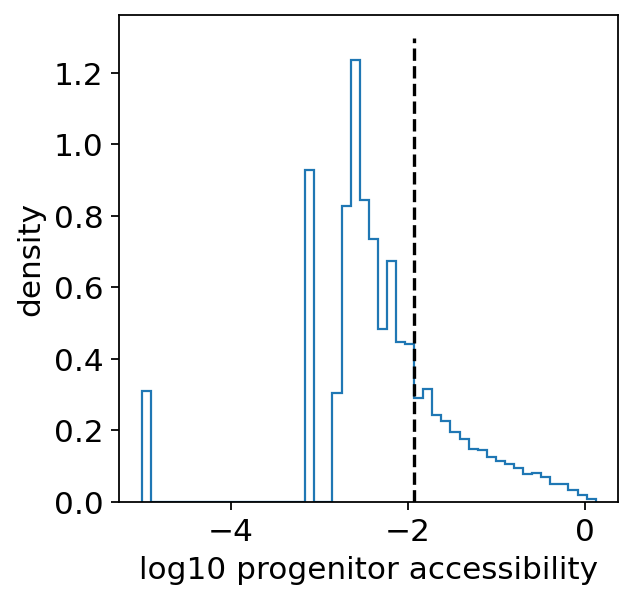

In [ ]:
pseudocount = 0.00001

coverage_progenitor = np.log(df_coverage_progenitor.sum(axis=1) + pseudocount) / np.log(10)
coverage_gastric = np.log(df_coverage_gastric.sum(axis=1) + pseudocount) / np.log(10)

h, bins = np.histogram(coverage_progenitor, bins = 50, density = True)
plt.stairs(h, bins)
ACCESSIBILITY_THRESHOLD = threshold_triangle([h, bins])
plt.plot([ACCESSIBILITY_THRESHOLD] * 2, plt.gca().get_ylim(), 'k--')
print("ACCESSIBILITY_THRESHOLD = " + str(np.power(10, ACCESSIBILITY_THRESHOLD) - pseudocount))
plt.xlabel("log10 progenitor accessibility")
plt.ylabel("density")
plt.grid(False)

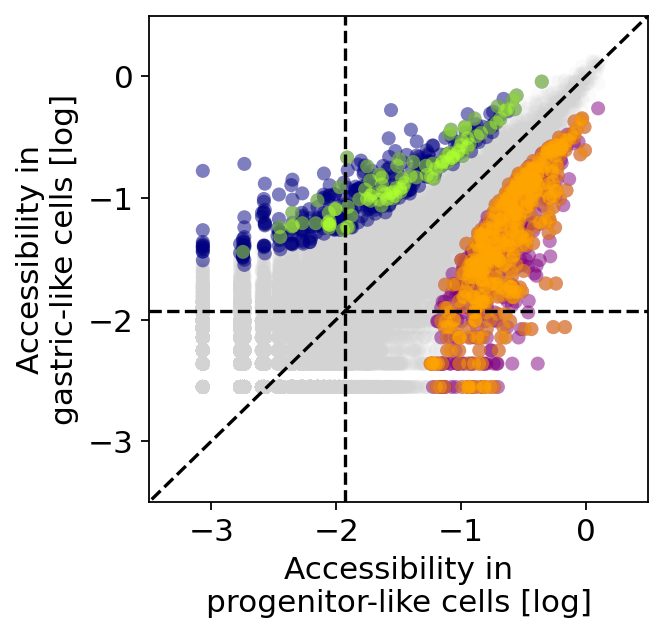

In [ ]:
s = 40

# Identify threshold for calling a p53 motif accessible
progenitor_filter = ismember(df_coverage_progenitor.index, progenitor_motifs)[1]
progenitor_filter = ismember(df_coverage_progenitor.index, bound_motifs)[1]
gastric_filter = (coverage_gastric > -6) & (coverage_progenitor > coverage_gastric)
pval_filter = ismember(df_coverage_progenitor.index, de.index[np.logical_not(np.isnan(de['padj']))])[1]

current_motifs = np.logical_not(ismember(df_coverage_progenitor.index, progenitor_motifs)[1]) & np.logical_not(ismember(df_coverage_progenitor.index, gastric_motifs)[1])
plt.scatter(coverage_progenitor[current_motifs], coverage_gastric[current_motifs], s = s, edgecolor='none', alpha = 0.1, color='lightgray', rasterized=True)

#current_motifs = ismember(df_coverage_progenitor.index, bound_motifs)[1]
#plt.scatter(coverage_progenitor[current_motifs], coverage_gastric[current_motifs], s = s, edgecolor='none')

current_motifs = ismember(df_coverage_progenitor.index, progenitor_motifs)[1]
plt.scatter(coverage_progenitor[current_motifs], coverage_gastric[current_motifs], s = s, edgecolor='none', alpha = 0.5, color='purple', rasterized=True)

current_motifs = ismember(df_coverage_progenitor.index, progenitor_bound)[1]
plt.scatter(coverage_progenitor[current_motifs], coverage_gastric[current_motifs], s = s, edgecolor='none', alpha = 0.5, color='orange', rasterized=True)

current_motifs = ismember(df_coverage_progenitor.index, gastric_motifs)[1]
plt.scatter(coverage_progenitor[current_motifs], coverage_gastric[current_motifs], s = s, edgecolor='none', alpha = 0.5, color='navy', rasterized=True)

current_motifs = ismember(df_coverage_progenitor.index, gastric_bound)[1]
plt.scatter(coverage_progenitor[current_motifs], coverage_gastric[current_motifs], s = s, edgecolor='none', alpha = 0.5, color='greenyellow', rasterized=True)

plt.xlim([-3.5,0.5])
plt.ylim([-3.5,0.5])

plt.plot([-8,1], [-8,1], 'k--')
plt.plot([ACCESSIBILITY_THRESHOLD] * 2, plt.gca().get_ylim(), 'k--')
plt.plot(plt.gca().get_xlim(), [ACCESSIBILITY_THRESHOLD] * 2, 'k--')

plt.grid(False)
plt.xlabel("Accessibility in\nprogenitor-like cells [log]")
plt.ylabel("Accessibility in\ngastric-like cells [log]")

os.makedirs("Figures", exist_ok=True)
#plt.savefig("Figures/multiome_PP20251110_p53_motif_annotated.pdf")

In [ ]:
np.power(10,ACCESSIBILITY_THRESHOLD) - pseudocount

np.float64(0.011751191416078171)

In [ ]:
df_final = pd.DataFrame({
    "motif_id": coverage_progenitor.index, 
    "coverage_progenitor": np.exp(coverage_progenitor.to_numpy()) - pseudocount,
    "coverage_gastric": np.exp(coverage_gastric.to_numpy()) - pseudocount,
    "progenitor_specific": ismember(coverage_progenitor.index, progenitor_motifs)[1],
    "gastric_specific": ismember(coverage_progenitor.index, gastric_motifs)[1],
    "p53_ChIP_200": de['p53_ChIP_200'][coverage_progenitor.index],
    "progenitor_accessible": coverage_progenitor.to_numpy() > ACCESSIBILITY_THRESHOLD,
    "gastric_accessible": coverage_gastric.to_numpy() > ACCESSIBILITY_THRESHOLD,
    "within_peaks": de['within_peaks'][coverage_progenitor.index],
    "motif_type": df_coverage.loc[coverage_progenitor.index, 'motif_type']
})
output_path = "../preprocessed/step4_p53_program/"
os.makedirs(output_path, exist_ok=True)
df_final.to_csv(os.path.join(output_path, "Reyes_multiome_p53_motif_annotated_v2.csv.gz"))